# Unemployment Analysis with Python

## Oasis Infobyte Data Science Internship – Task 2

### Objective

The objective of this project is to analyze unemployment trends in India
across different regions and time periods and to study the impact of
the COVID-19 period on unemployment.

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

df = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

print("Dataset loaded successfully.")

Libraries imported successfully.
Dataset loaded successfully.


In [3]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [4]:
df.shape

(267, 9)

In [5]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    str    
 1    Date                                     267 non-null    str    
 2    Frequency                                267 non-null    str    
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    str    
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), str(4)
memory usage: 26.0 KB


# Exploratory Data Analysis

Exploratory Data Analysis is performed to understand unemployment
patterns across different regions and time periods.

In [25]:
print(df.shape)
print(df.columns.tolist())

(267, 9)
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


In [26]:
df.rename(
    columns={df.columns[3]: "Unemployment_Rate"},
    inplace=True
)

In [27]:
print(df.columns.tolist())

['Region', ' Date', ' Frequency', 'Unemployment_Rate', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


In [28]:
region_avg = (
    df.groupby("Region")["Unemployment_Rate"]
    .mean()
    .sort_values(ascending=False)
)

region_avg

Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Goa                 12.167000
Punjab              11.981000
Uttarakhand         11.156000
West Bengal         10.192000
Sikkim               9.792500
Uttar Pradesh        9.737000
Kerala               9.434000
Andhra Pradesh       8.664000
Maharashtra          7.979000
Chhattisgarh         7.819000
Karnataka            7.668000
Madhya Pradesh       6.854000
Telangana            6.833000
Odisha               6.462000
Gujarat              6.376000
Assam                4.856000
Meghalaya            3.866000
Name: Unemployment_Rate, dtype: float64

In [29]:
top10_states = region_avg.head(10)

top10_states

Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Name: Unemployment_Rate, dtype: float64

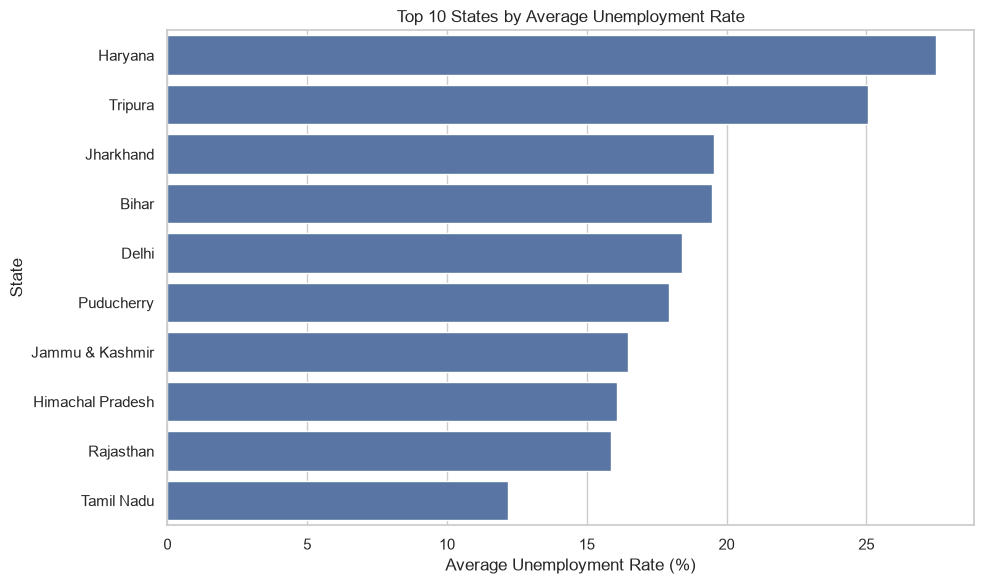

In [30]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top10_states.values,
    y=top10_states.index
)

plt.title("Top 10 States by Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

### Observation

The chart shows the ten regions with the highest average unemployment rates in the dataset. The regions at the top have comparatively higher unemployment levels than the remaining regions.

In [35]:
# Remove extra spaces from all column names
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Unemployment_Rate', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


In [48]:
df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%m-%Y",
    errors="coerce"
)
# Calculate average unemployment rate for each date
monthly_unemployment = (
    df.groupby("Date")["Unemployment_Rate"]
      .mean()
      .sort_index()
)

monthly_unemployment

Date
2020-01-31     9.196538
2020-02-29     9.266154
2020-03-31    10.782593
2020-04-30    22.236154
2020-05-31    23.244444
2020-06-30    10.911111
2020-07-31     9.834444
2020-08-31    10.313333
2020-09-30     8.705926
2020-10-31     8.026296
Name: Unemployment_Rate, dtype: float64

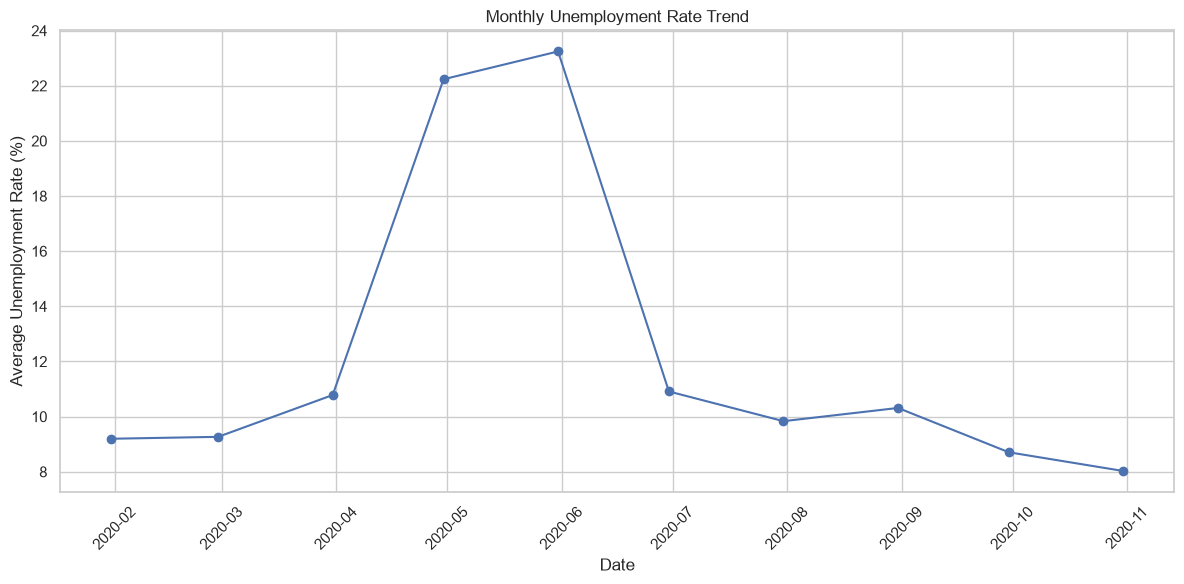

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_unemployment.index,
    monthly_unemployment.values,
    marker="o"
)

plt.title("Monthly Unemployment Rate Trend")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

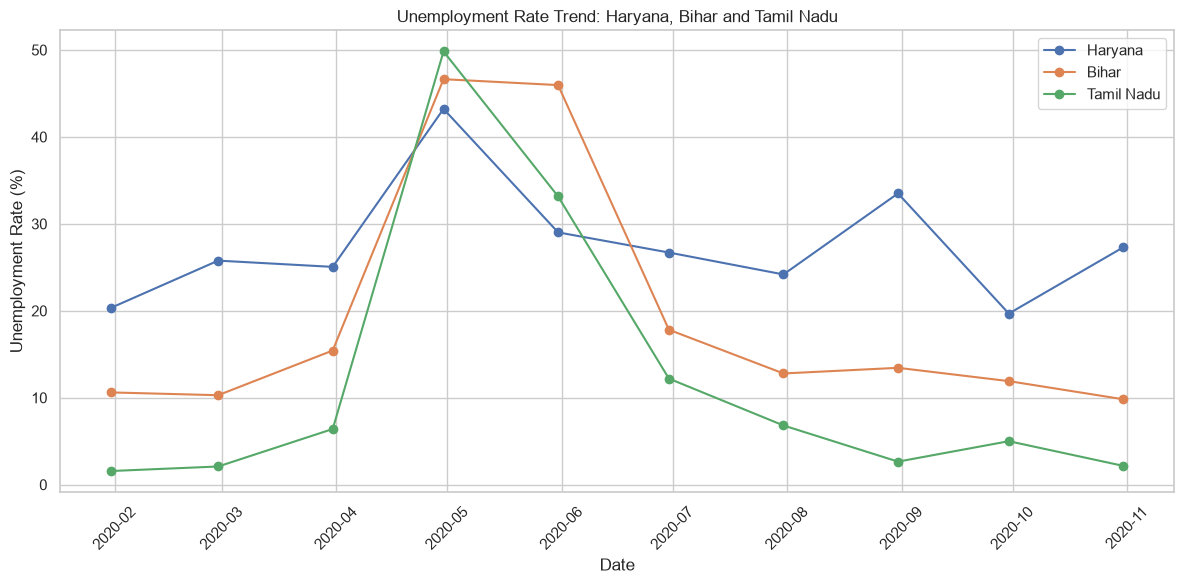

In [38]:
# Select three regions for comparison
selected_regions = ["Haryana", "Bihar", "Tamil Nadu"]

region_trend = df[df["Region"].isin(selected_regions)]

# Create the time-series chart
plt.figure(figsize=(12, 6))

for region in selected_regions:
    region_data = region_trend[region_trend["Region"] == region]
    plt.plot(
        region_data["Date"],
        region_data["Unemployment_Rate"],
        marker="o",
        label=region
    )

plt.title("Unemployment Rate Trend: Haryana, Bihar and Tamil Nadu")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [39]:
# Select the 10 states with the highest average unemployment rate

top_10_states = region_avg.head(10)

top_10_states

Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Name: Unemployment_Rate, dtype: float64

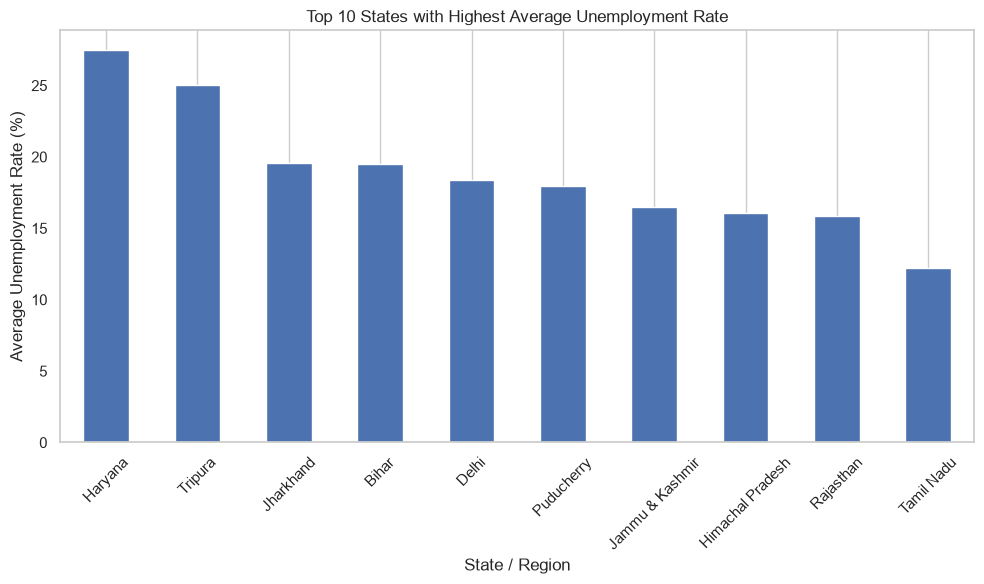

In [40]:
plt.figure(figsize=(10, 6))

top_10_states.plot(kind="bar")

plt.title("Top 10 States with Highest Average Unemployment Rate")
plt.xlabel("State / Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [41]:
# Select the required numerical columns
correlation_data = df[
    [
        "Unemployment_Rate",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
]

# Calculate correlation matrix
correlation_matrix = correlation_data.corr()

correlation_matrix

,Unemployment_Rate,Estimated Employed,Estimated Labour Participation Rate (%)
Unemployment_Rate,1.000000,-0.245176,-0.073540
Estimated Employed,-0.245176,1.000000,-0.047948
Estimated Labour Participation Rate (%),-0.073540,-0.047948,1.000000


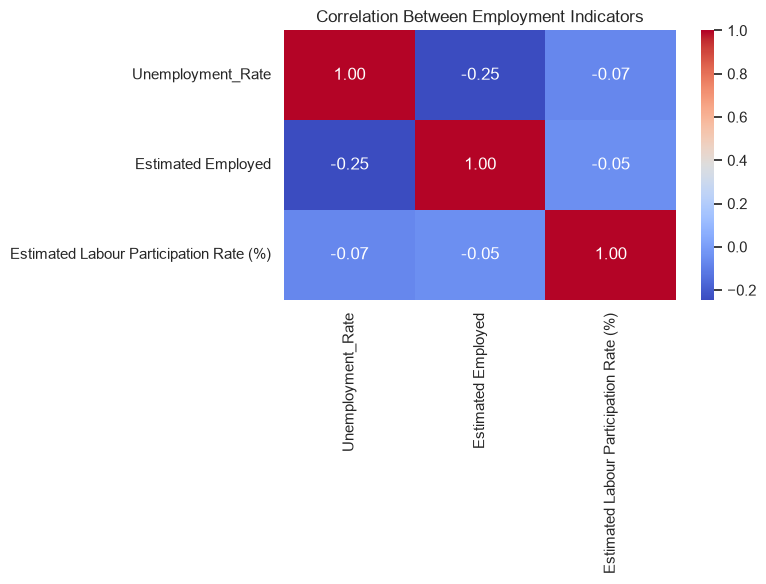

In [42]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Employment Indicators")

plt.tight_layout()
plt.show()

In [43]:
pre_covid = df[df["Date"] < "2020-03-01"]

covid_period = df[df["Date"] >= "2020-03-01"]

print("Pre-COVID records:", len(pre_covid))
print("COVID-period records:", len(covid_period))

Pre-COVID records: 52
COVID-period records: 215


In [44]:
pre_covid_avg = pre_covid["Unemployment_Rate"].mean()
covid_avg = covid_period["Unemployment_Rate"].mean()

print("Pre-COVID average unemployment rate:",
      round(pre_covid_avg, 2), "%")

print("COVID-period average unemployment rate:",
      round(covid_avg, 2), "%")

Pre-COVID average unemployment rate: 9.23 %
COVID-period average unemployment rate: 12.96 %


In [45]:
change = covid_avg - pre_covid_avg

print("Change in unemployment rate:",
      round(change, 2), "percentage points")

Change in unemployment rate: 3.73 percentage points


In [46]:
covid_comparison = pd.DataFrame({
    "Period": ["Pre-COVID", "COVID Period"],
    "Average Unemployment Rate": [
        pre_covid_avg,
        covid_avg
    ]
})

covid_comparison

,Period,Average Unemployment Rate
0,Pre-COVID,9.231346
1,COVID Period,12.963860


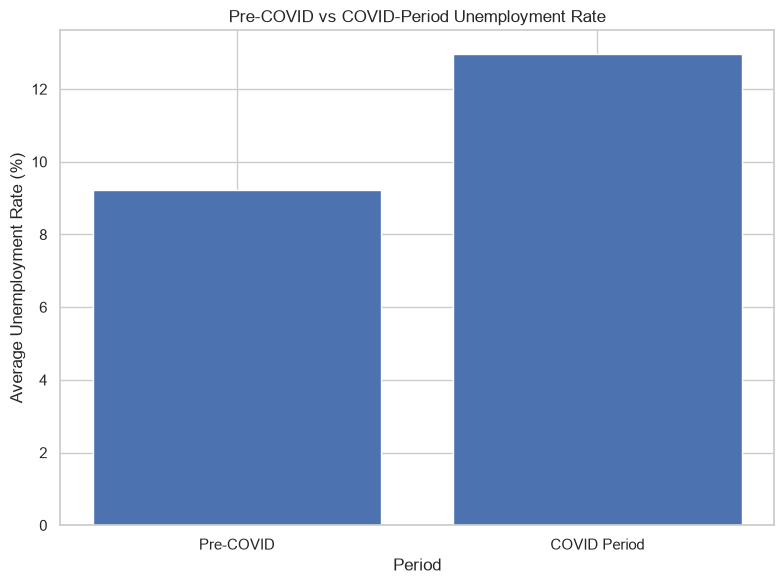

In [47]:
plt.figure(figsize=(8, 6))

plt.bar(
    covid_comparison["Period"],
    covid_comparison["Average Unemployment Rate"]
)

plt.title("Pre-COVID vs COVID-Period Unemployment Rate")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

plt.tight_layout()
plt.show()

## Key Observations

- The analysis shows differences in average unemployment rates across Indian states and regions.
- Haryana recorded the highest average unemployment rate among the regions in the dataset.
- The monthly trend shows that unemployment rates changed considerably over time.
- The selected-state comparison highlights different unemployment patterns for Haryana, Bihar, and Tamil Nadu.
- The correlation analysis shows the relationship between unemployment rate, estimated employment, and labour participation rate.
- The comparison between the pre-COVID and COVID periods helps identify the change in unemployment during the COVID-19 period.

## Conclusion

This analysis explored unemployment trends across different regions of India using Python. 
The analysis included regional averages, monthly unemployment trends, comparison of selected regions, 
the top 10 regions with the highest average unemployment rates, correlation between employment indicators, 
and a comparison of unemployment before and during the COVID-19 period.

Overall, the analysis provides insights into how unemployment varied across regions and changed over time.